# Project 2 — SBA Loan Default Prediction 
**Author:** Mamadou Bassirou Diallo  
  

---

## Table of Contents

1. [Setup & Imports](#1)
2. [Load Data](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Cleaning](#4)
5. [Feature Engineering](#5)
6. [Train / Validation / Test Split](#6)
7. [Preprocessing](#7)
8. [XGBoost Model 1 — Hyperparameter Tuning (Optuna)](#8)
9. [XGBoost Model 2 — Hyperparameter Tuning (Optuna)](#9)
10. [Final Model Training (Low LR + Early Stopping)](#10)
11. [Ensemble Weight Optimization](#11)
12. [Threshold Optimization (F1)](#12)
13. [Test-Set Evaluation](#13)
14. [Model Interpretation — SHAP & Permutation Importance](#14)
15. [Individual Observation Analysis](#15)
16. [Residual / Error Analysis](#16)
17. [Surrogate Model on Misclassified Records](#17)
18. [Save Artifacts](#18)
19. [Summary & Conclusions](#19)

## 1. Setup & Imports <a id='1'></a>

In [1]:
import json
import pickle
import warnings
import zipfile
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 100
SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path(".").resolve()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("XGBoost:", xgb.__version__)
print("SHAP:", shap.__version__)
print("Optuna:", optuna.__version__)
print("Artifacts dir:", ARTIFACTS_DIR)


XGBoost: 3.1.2
SHAP: 0.51.0
Optuna: 4.6.0
Artifacts dir: C:\Users\bassi\BUAN-6341-ML\project-2-bass990-1\artifacts


## 2. Load Data <a id='2'></a>

We load the full training dataset from the zip archive and inspect its basic structure.


In [2]:
ZIP_PATH = PROJECT_ROOT / "data" / "SBA_loans_project_2.zip"
HOLDOUT_PATH = PROJECT_ROOT / "data" / "SBA_loans_project_2_holdout_students_valid.csv"

with zipfile.ZipFile(ZIP_PATH) as z:
    with z.open(z.namelist()[0]) as f:
        df_raw = pd.read_csv(f)

print(f"Training data shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)


Training data shape: (799356, 20)
Columns: ['index', 'City', 'State', 'Zip', 'Bank', 'BankState', 'NAICS', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'BalanceGross', 'GrAppv', 'SBA_Appv', 'MIS_Status']


,index,City,State,Zip,Bank,BankState,NAICS,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementGross,BalanceGross,GrAppv,SBA_Appv,MIS_Status
0,0,FORT LEE,NJ,7024,BNB HANA BANK NATL ASSOC,NJ,425120,2,1.0,0,2,1,1,Y,N,10000.0,0.0,10000.0,5000.0,0
1,1,WESTWEGO,LA,70094,JEDCO DEVELOPMENT CORPORATION,LA,812331,62,1.0,6,0,1,1,0,N,353000.0,0.0,353000.0,353000.0,0
2,2,DENVER,CO,80209,WELLS FARGO BANK NATL ASSOC,SD,541611,4,1.0,1,4,1,1,Y,N,100000.0,0.0,100000.0,50000.0,0


## 3. Data Quality Checks <a id='3'></a>

Before any transformation we examine: missing values, class balance, data types, and
suspicious/inconsistent values.


In [3]:
print("=== Shape ===")
print(df_raw.shape)

print("\n=== Dtypes ===")
print(df_raw.dtypes)

print("\n=== Missing values ===")
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0])

print("\n=== Target distribution ===")
vc = df_raw["MIS_Status"].value_counts()
print(vc)
imbalance_ratio = vc[0] / vc[1]
print(f"Class imbalance ratio (0:1) = {imbalance_ratio:.2f}")


=== Shape ===
(799356, 20)

=== Dtypes ===
index                  int64
City                  object
State                 object
Zip                    int64
Bank                  object
BankState             object
NAICS                  int64
NoEmp                  int64
NewExist             float64
CreateJob              int64
RetainedJob            int64
FranchiseCode          int64
UrbanRural             int64
RevLineCr             object
LowDoc                object
DisbursementGross    float64
BalanceGross         float64
GrAppv               float64
SBA_Appv             float64
MIS_Status             int64
dtype: object

=== Missing values ===
City           25
State          12
Bank         1402
BankState    1408
NewExist      114
RevLineCr    4025
LowDoc       2300
dtype: int64

=== Target distribution ===
MIS_Status
0    659351
1    140005
Name: count, dtype: int64
Class imbalance ratio (0:1) = 4.71


In [4]:
print("=== RevLineCr unique values ===")
print(df_raw["RevLineCr"].value_counts(dropna=False).to_string())

print("\n=== LowDoc unique values ===")
print(df_raw["LowDoc"].value_counts(dropna=False).to_string())

print("\n=== NewExist unique values ===")
print(df_raw["NewExist"].value_counts(dropna=False).to_string())

print("\n=== UrbanRural unique values ===")
print(df_raw["UrbanRural"].value_counts(dropna=False).to_string())

print("\n=== DisbursementGross zeros ===", (df_raw["DisbursementGross"] == 0).sum())
print("=== GrAppv zeros ===", (df_raw["GrAppv"] == 0).sum())
print("=== FranchiseCode==0 ===", (df_raw["FranchiseCode"] == 0).sum())


=== RevLineCr unique values ===
RevLineCr
N      373816
0      228950
Y      178985
T       13523
NaN      4025
1          19
R          12
`          10
2           5
C           2
.           1
A           1
7           1
4           1
,           1
5           1
3           1
Q           1
-           1

=== LowDoc unique values ===
LowDoc
N      696070
Y       97961
NaN      2300
0        1316
C         681
S         526
A         436
R          65
1           1

=== NewExist unique values ===
NewExist
1.0    573237
2.0    225071
0.0       934
NaN       114

=== UrbanRural unique values ===
UrbanRural
1    418275
0    287373
2     93708

=== DisbursementGross zeros === 171
=== GrAppv zeros === 0
=== FranchiseCode==0 === 185609


**Findings:**
- `RevLineCr` and `LowDoc` contain garbage values beyond 'Y'/'N' — we will normalise to Y/N/Unknown.
- `NewExist` has a small number of 0.0 values (not a valid code) and 114 NaN — both mapped to mode (1.0 = existing business).
- Class ratio is ~4.7:1 (non-default to default), meaning the dataset is moderately imbalanced.
- `FranchiseCode==0` means "not a franchise"; `==1` means unknown; `>1` means a specific franchise.
- `NAICS==0` (unknown industry) — we will capture these with a missing-industry indicator.


## 4. Train / Validation / Test Split <a id='4'></a>

We split **before** fitting any encoders, imputers, or feature transformations to prevent data leakage.
Split ratio: **70% train | 15% validation | 15% test** (stratified on `MIS_Status`).


In [5]:
X_all = df_raw.drop(columns=["MIS_Status"])
y_all = df_raw["MIS_Status"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Val   default rate: {y_val.mean():.4f}")
print(f"Test  default rate: {y_test.mean():.4f}")


Train: 559,548  Val: 119,904  Test: 119,904
Train default rate: 0.1751
Val   default rate: 0.1751
Test  default rate: 0.1751


## 5. Data Cleaning & Preparation <a id='5'></a>

All cleaning logic is implemented as stateless (rule-based) functions that can be
re-applied identically during scoring.


In [6]:
def clean_revlinecr(series):
    """Normalise RevLineCr to Y/N/U (unknown)."""
    s = series.copy().astype(str).str.strip().str.upper()
    return s.map(lambda x: x if x in ("Y", "N") else "U")

def clean_lowdoc(series):
    """Normalise LowDoc to Y/N/U (unknown)."""
    s = series.copy().astype(str).str.strip().str.upper()
    return s.map(lambda x: x if x in ("Y", "N") else "U")

def clean_newexist(series):
    """Map 0.0 -> NaN so it is handled by imputation. Keep 1.0, 2.0, NaN."""
    s = series.copy()
    s[s == 0.0] = np.nan
    return s

def clean_naics(series):
    """Replace NAICS == 0 with NaN (unknown industry)."""
    s = series.copy().astype(float)
    s[s == 0] = np.nan
    return s

def clean_df(df):
    out = df.copy()
    out["RevLineCr"] = clean_revlinecr(out["RevLineCr"])
    out["LowDoc"]    = clean_lowdoc(out["LowDoc"])
    out["NewExist"]  = clean_newexist(out["NewExist"])
    out["NAICS"]     = clean_naics(out["NAICS"])
    # fill simple string NaNs
    out["City"]      = out["City"].fillna("UNKNOWN")
    out["State"]     = out["State"].fillna("UNK")
    out["Bank"]      = out["Bank"].fillna("UNKNOWN")
    out["BankState"] = out["BankState"].fillna("UNK")
    return out

X_train_c = clean_df(X_train)
X_val_c   = clean_df(X_val)
X_test_c  = clean_df(X_test)

print("Cleaning done.")
print("RevLineCr (train):", X_train_c["RevLineCr"].value_counts().to_dict())
print("LowDoc    (train):", X_train_c["LowDoc"].value_counts().to_dict())
print("NewExist  NaN:", X_train_c["NewExist"].isna().sum())


Cleaning done.
RevLineCr (train): {'N': 261764, 'U': 172670, 'Y': 125114}
LowDoc    (train): {'N': 487347, 'Y': 68520, 'U': 3681}
NewExist  NaN: 736


## 6. Feature Engineering <a id='6'></a>

We create **15 engineered features** (well above the 10 required). Each is justified below.
Encoding-only transformations (one-hot, label, target) do **not** count; all features below add
substantive business information.

| # | Feature | Rationale |
|---|---------|-----------|
| 1 | `sba_coverage_ratio` | Fraction of gross approval backed by SBA — higher coverage may reduce lender risk appetite |
| 2 | `disbursement_ratio` | Actual disbursement vs approved — under-disbursement may signal borrower problems |
| 3 | `balance_ratio` | Residual balance relative to disbursement — loans still carrying balance may be riskier |
| 4 | `is_franchise` | Binary franchise indicator (FranchiseCode > 1) |
| 5 | `naics_sector` | 2-digit NAICS sector (industry group) — extracted from 6-digit code |
| 6 | `naics_unknown` | Indicator: NAICS was missing/zero — unknown industry is itself a risk signal |
| 7 | `total_jobs` | CreateJob + RetainedJob — total employment impact |
| 8 | `jobs_per_employee` | total_jobs / (NoEmp+1) — job impact relative to firm size |
| 9 | `new_business` | NewExist==2 (new business) — new businesses default at higher rates |
| 10 | `same_state_bank` | Lender is headquartered in same state as borrower — local knowledge effect |
| 11 | `log_disbursement` | log1p(DisbursementGross) — skew reduction for large loan amounts |
| 12 | `log_employees` | log1p(NoEmp) — skew reduction for firm size |
| 13 | `sba_to_disbursement_ratio` | SBA_Appv / (DisbursementGross+1) — SBA exposure relative to actual loan |
| 14 | `rev_line_flag` | Binary: RevLineCr == 'Y' |
| 15 | `low_doc_flag` | Binary: LowDoc == 'Y' — low-documentation loans carry higher default risk |


In [7]:
def engineer_features(df):
    """Apply all engineered features. Stateless — safe to reuse in scoring."""
    out = df.copy()

    # 1. SBA coverage ratio
    out["sba_coverage_ratio"] = np.where(
        out["GrAppv"] > 0, out["SBA_Appv"] / out["GrAppv"], 0.0
    )
    # 2. Disbursement vs gross approved
    out["disbursement_ratio"] = np.where(
        out["GrAppv"] > 0, out["DisbursementGross"] / out["GrAppv"], 0.0
    )
    # 3. Balance ratio
    out["balance_ratio"] = out["BalanceGross"] / (out["DisbursementGross"] + 1.0)

    # 4. Is franchise (specific)
    out["is_franchise"] = (out["FranchiseCode"] > 1).astype(int)

    # 5 & 6. NAICS sector + unknown flag
    out["naics_unknown"] = out["NAICS"].isna().astype(int)
    out["naics_sector"] = (out["NAICS"].fillna(0) // 10000).astype(int)

    # 7 & 8. Job features
    out["total_jobs"] = out["CreateJob"] + out["RetainedJob"]
    out["jobs_per_employee"] = out["total_jobs"] / (out["NoEmp"] + 1.0)

    # 9. New business
    out["new_business"] = (out["NewExist"].fillna(1.0) == 2.0).astype(int)

    # 10. Same-state bank
    out["same_state_bank"] = (out["State"] == out["BankState"]).astype(int)

    # 11 & 12. Log transforms
    out["log_disbursement"] = np.log1p(out["DisbursementGross"])
    out["log_employees"]    = np.log1p(out["NoEmp"])

    # 13. SBA to disbursement
    out["sba_to_disbursement_ratio"] = out["SBA_Appv"] / (out["DisbursementGross"] + 1.0)

    # 14 & 15. Binary flags from cleaned categoricals
    out["rev_line_flag"] = (out["RevLineCr"] == "Y").astype(int)
    out["low_doc_flag"]  = (out["LowDoc"]    == "Y").astype(int)

    return out

X_train_fe = engineer_features(X_train_c)
X_val_fe   = engineer_features(X_val_c)
X_test_fe  = engineer_features(X_test_c)

engineered_cols = [
    "sba_coverage_ratio", "disbursement_ratio", "balance_ratio",
    "is_franchise", "naics_unknown", "naics_sector",
    "total_jobs", "jobs_per_employee", "new_business",
    "same_state_bank", "log_disbursement", "log_employees",
    "sba_to_disbursement_ratio", "rev_line_flag", "low_doc_flag"
]
print(f"Engineered {len(engineered_cols)} new features.")
X_train_fe[engineered_cols].describe().round(3)


Engineered 15 new features.


,sba_coverage_ratio,disbursement_ratio,balance_ratio,is_franchise,naics_unknown,naics_sector,total_jobs,jobs_per_employee,new_business,same_state_bank,log_disbursement,log_employees,sba_to_disbursement_ratio,rev_line_flag,low_doc_flag
count,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000,559548.000
mean,0.709,1.184,0.000,0.058,0.225,39.619,19.818,2.496,0.281,0.527,11.478,1.837,22.547,0.224,0.122
std,0.174,0.610,0.002,0.233,0.417,26.299,484.922,90.127,0.450,0.499,1.273,0.974,2563.360,0.417,0.328
min,0.028,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.028,0.000,0.000
25%,0.500,1.000,0.000,0.000,0.000,23.000,0.000,0.000,0.000,0.000,10.645,1.099,0.500,0.000,0.000
50%,0.750,1.000,0.000,0.000,0.000,44.000,2.000,0.500,0.000,1.000,11.513,1.609,0.750,0.000,0.000
75%,0.850,1.000,0.000,0.000,0.000,56.000,6.000,0.964,1.000,1.000,12.384,2.398,0.850,0.000,0.000
max,1.000,13.902,1.000,1.000,1.000,92.000,17600.000,8800.000,1.000,1.000,16.164,9.210,730500.000,1.000,1.000


## 7. Preprocessing Pipeline <a id='7'></a>

Steps:
1. **Drop** `City`, `Bank` (extremely high cardinality, too noisy for direct encoding)
2. **Impute** `NewExist` mode, `naics_sector` 0 already handled
3. **Label-encode** ordinal/nominal categorical columns: `State`, `BankState`, `RevLineCr`, `LowDoc`
4. **Impute** remaining float NaN with median

All encoders/imputers are **fitted on training data only**, then applied to val/test.


In [8]:
CATEGORICAL_COLS = ["State", "BankState", "RevLineCr", "LowDoc"]
DROP_COLS        = ["City", "Bank", "index"]   # index is ID not a feature

# Imputation stats — computed on train only
NEWEXIST_MODE = X_train_fe["NewExist"].mode()[0]

label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    # add unseen category placeholder
    train_vals = X_train_fe[col].fillna("MISSING").astype(str)
    le.fit(list(train_vals.unique()) + ["UNSEEN"])
    label_encoders[col] = le

def preprocess(df, fit=False):
    """Transform features to model-ready matrix. fit=False uses pre-fitted encoders."""
    out = df.copy()

    # Drop ID / text columns
    out = out.drop(columns=[c for c in DROP_COLS if c in out.columns], errors="ignore")
    # Drop target if present
    out = out.drop(columns=["MIS_Status"], errors="ignore")

    # Impute NewExist
    out["NewExist"] = out["NewExist"].fillna(NEWEXIST_MODE)

    # Label encode
    for col in CATEGORICAL_COLS:
        le = label_encoders[col]
        vals = out[col].fillna("MISSING").astype(str)
        # map unseen values to UNSEEN class
        vals = vals.map(lambda v, le=le: v if v in le.classes_ else "UNSEEN")
        out[col] = le.transform(vals)

    # Fill remaining NaN with median (fitted on training)
    for col in out.select_dtypes(include=[np.number]).columns:
        if out[col].isna().any():
            out[col] = out[col].fillna(out[col].median())

    return out

X_train_pp = preprocess(X_train_fe)
X_val_pp   = preprocess(X_val_fe)
X_test_pp  = preprocess(X_test_fe)

# Compute median fill values on training for scoring
MEDIAN_FILL = X_train_pp.median().to_dict()

print(f"Feature matrix shape: {X_train_pp.shape}")
print(f"Columns: {X_train_pp.columns.tolist()}")
print(f"Any NaN in train: {X_train_pp.isna().any().any()}")
X_train_pp.head(3)


Feature matrix shape: (559548, 31)
Columns: ['State', 'Zip', 'BankState', 'NAICS', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'BalanceGross', 'GrAppv', 'SBA_Appv', 'sba_coverage_ratio', 'disbursement_ratio', 'balance_ratio', 'is_franchise', 'naics_unknown', 'naics_sector', 'total_jobs', 'jobs_per_employee', 'new_business', 'same_state_bank', 'log_disbursement', 'log_employees', 'sba_to_disbursement_ratio', 'rev_line_flag', 'low_doc_flag']
Any NaN in train: False


,State,Zip,BankState,NAICS,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,...,naics_sector,total_jobs,jobs_per_employee,new_business,same_state_bank,log_disbursement,log_employees,sba_to_disbursement_ratio,rev_line_flag,low_doc_flag
722592,24,63376,27,512110.0,5,1.0,2,3,1,0,...,0,5,0.833333,0,1,11.251574,1.791759,0.999987,0,0
325055,3,85281,40,512110.0,6,1.0,0,0,1,0,...,0,0,0.000000,0,0,12.821261,1.945910,0.699998,0,0
667573,3,85014,17,236116.0,1,2.0,0,1,0,1,...,23,1,0.500000,1,0,11.354422,0.693147,0.146469,1,0


In [9]:
FEATURE_NAMES = X_train_pp.columns.tolist()
print(f"Total features: {len(FEATURE_NAMES)}")

# Build XGBoost DMatrix objects
dtrain = xgb.DMatrix(X_train_pp, label=y_train, feature_names=FEATURE_NAMES)
dval   = xgb.DMatrix(X_val_pp,   label=y_val,   feature_names=FEATURE_NAMES)
dtest  = xgb.DMatrix(X_test_pp,  label=y_test,  feature_names=FEATURE_NAMES)

# Class imbalance ratio for scale_pos_weight
SPW = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight (0/1 ratio): {SPW:.3f}")


# ── Stratified tuning subsample (~100K rows) ────────────────────────────
# 60 Optuna trials x 500 rounds on 560K rows is very slow.
# We train each trial on a 100K stratified subsample and evaluate on the full
# validation set so AUCPR comparisons stay honest.
# Final models always train on the full dtrain.
_rng_tune = np.random.default_rng(SEED)
_idx_0 = np.where(y_train.values == 0)[0]
_idx_1 = np.where(y_train.values == 1)[0]
_tune_idx = np.concatenate([
    _rng_tune.choice(_idx_0, size=min(80_000, len(_idx_0)), replace=False),
    _rng_tune.choice(_idx_1, size=min(20_000, len(_idx_1)), replace=False),
])
_rng_tune.shuffle(_tune_idx)
X_tune = X_train_pp.iloc[_tune_idx].reset_index(drop=True)
y_tune = y_train.values[_tune_idx]
dtrain_tune = xgb.DMatrix(X_tune, label=y_tune, feature_names=FEATURE_NAMES)
print(f"Tuning subsample: {len(_tune_idx):,} rows | default rate: {y_tune.mean():.4f}")
print("Full dtrain is used for final model training only.")


Total features: 31
scale_pos_weight (0/1 ratio): 4.709
Tuning subsample: 100,000 rows | default rate: 0.2000
Full dtrain is used for final model training only.


## 8. XGBoost Model 1 — Hyperparameter Tuning (Optuna) <a id='8'></a>

**Model 1 design:** Deep trees with class-imbalance compensation via `scale_pos_weight`.
Search space focuses on tree depth (5–9), regularisation, and subsampling.
Objective: **AUCPR** on validation set. Early stopping with 30 rounds to speed exploration.
We run **30 Optuna trials** for Model 1.


In [10]:
def objective_m1(trial):
    # Trained on 100K subsample for speed; evaluated on full validation for honest AUCPR.
    params = {
        "objective":        "binary:logistic",
        "eval_metric":      "aucpr",
        "tree_method":      "hist",
        "seed":             SEED,
        "scale_pos_weight": SPW,
        "max_depth":        trial.suggest_int("max_depth", 5, 9),
        "eta":              trial.suggest_float("eta", 0.05, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "lambda":           trial.suggest_float("lambda", 0.5, 5.0),
        "alpha":            trial.suggest_float("alpha", 0.0, 2.0),
        "gamma":            trial.suggest_float("gamma", 0.0, 2.0),
    }
    evals_result = {}
    model = xgb.train(
        params,
        dtrain_tune,                # 100K subsample -- fast exploration
        num_boost_round=300,        # reduced from 500 for tuning speed
        evals=[(dval, "val")],      # full validation set for honest AUCPR
        early_stopping_rounds=20,  # tighter patience during exploration
        evals_result=evals_result,
        verbose_eval=False,
    )
    best_aucpr = max(evals_result["val"]["aucpr"])
    trial.set_user_attr("best_round", model.best_iteration)
    return best_aucpr

study_m1 = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_m1.optimize(objective_m1, n_trials=30, show_progress_bar=False)

print(f"Model 1 best AUCPR (val): {study_m1.best_value:.5f}")
print("Best params:", study_m1.best_params)


Model 1 best AUCPR (val): 0.54869
Best params: {'max_depth': 9, 'eta': 0.05187632371616001, 'subsample': 0.9535531575949361, 'colsample_bytree': 0.5012506127640156, 'min_child_weight': 10, 'lambda': 4.19082837681889, 'alpha': 1.8643661321133567, 'gamma': 1.6785827327526508}


In [11]:
# Tuning results table
m1_trials = (
    pd.DataFrame([{**t.params, "aucpr": t.value, "best_round": t.user_attrs.get("best_round", -1)}
                  for t in study_m1.trials])
    .sort_values("aucpr", ascending=False)
)
print("Top 10 Model 1 trials:")
m1_trials.head(10).round(4)


Top 10 Model 1 trials:


,max_depth,eta,subsample,colsample_bytree,min_child_weight,lambda,alpha,gamma,aucpr,best_round
21,9,0.0519,0.9536,0.5013,10,4.1908,1.8644,1.6786,0.5487,265
23,9,0.0503,0.9525,0.5513,9,4.1846,1.8738,1.4180,0.5484,285
12,9,0.0504,0.9290,0.5018,10,3.9332,1.9942,1.4987,0.5483,299
13,9,0.0531,0.9088,0.5049,8,3.6335,1.9987,1.4417,0.5480,294
22,9,0.0593,0.8655,0.5001,10,4.0685,1.7869,1.6310,0.5476,264
10,9,0.0505,0.9878,0.5090,10,4.5845,1.9195,1.9535,0.5473,291
28,9,0.0500,0.9163,0.7961,10,3.0722,1.6296,1.0619,0.5473,277
17,9,0.0597,0.9301,0.6899,9,2.4528,1.0037,1.1993,0.5471,173
25,9,0.0610,0.8506,0.5513,10,3.0583,1.8495,1.3425,0.5470,264
24,8,0.0777,0.9461,0.5509,9,4.3057,1.6270,1.7255,0.5466,179


## 9. XGBoost Model 2 — Hyperparameter Tuning (Optuna) <a id='9'></a>

**Model 2 design:** Shallower trees, stronger regularisation, **no** `scale_pos_weight`
(the class imbalance is handled differently — by letting the loss weigh naturally).
This creates meaningful diversity with Model 1:
- Shallower trees (max_depth 2–5) vs deeper (5–9)
- No imbalance compensation vs scale_pos_weight ≈ 4.7
- Stronger L2/L1 regularisation

We run **30 Optuna trials** for Model 2, giving **60 total trials** across both models.


In [12]:
def objective_m2(trial):
    # Trained on 100K subsample for speed; evaluated on full validation for honest AUCPR.
    params = {
        "objective":        "binary:logistic",
        "eval_metric":      "aucpr",
        "tree_method":      "hist",
        "seed":             SEED,
        # No scale_pos_weight -- intentional diversity vs Model 1
        "max_depth":        trial.suggest_int("max_depth", 2, 5),
        "eta":              trial.suggest_float("eta", 0.05, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.7),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 50),
        "lambda":           trial.suggest_float("lambda", 3.0, 10.0),
        "alpha":            trial.suggest_float("alpha", 0.5, 5.0),
        "gamma":            trial.suggest_float("gamma", 1.0, 5.0),
    }
    evals_result = {}
    model = xgb.train(
        params,
        dtrain_tune,                # 100K subsample -- fast exploration
        num_boost_round=300,        # reduced from 500 for tuning speed
        evals=[(dval, "val")],      # full validation set for honest AUCPR
        early_stopping_rounds=20,  # tighter patience during exploration
        evals_result=evals_result,
        verbose_eval=False,
    )
    best_aucpr = max(evals_result["val"]["aucpr"])
    trial.set_user_attr("best_round", model.best_iteration)
    return best_aucpr

study_m2 = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_m2.optimize(objective_m2, n_trials=30, show_progress_bar=False)

print(f"Model 2 best AUCPR (val): {study_m2.best_value:.5f}")
print("Best params:", study_m2.best_params)
print(f"\nTotal Optuna trials: {len(study_m1.trials) + len(study_m2.trials)}")


Model 2 best AUCPR (val): 0.53521
Best params: {'max_depth': 5, 'eta': 0.10846991510908928, 'subsample': 0.7270746445032663, 'colsample_bytree': 0.5139004302843629, 'min_child_weight': 23, 'lambda': 6.940752368815234, 'alpha': 0.9063011714547895, 'gamma': 2.7836079173838133}

Total Optuna trials: 60


In [13]:
m2_trials = (
    pd.DataFrame([{**t.params, "aucpr": t.value, "best_round": t.user_attrs.get("best_round", -1)}
                  for t in study_m2.trials])
    .sort_values("aucpr", ascending=False)
)
print("Top 10 Model 2 trials:")
m2_trials.head(10).round(4)


Top 10 Model 2 trials:


,max_depth,eta,subsample,colsample_bytree,min_child_weight,lambda,alpha,gamma,aucpr,best_round
28,5,0.1085,0.7271,0.5139,23,6.9408,0.9063,2.7836,0.5352,299
23,5,0.1958,0.6857,0.5388,33,6.2944,2.2137,3.3989,0.5325,298
25,5,0.1952,0.7317,0.4502,30,7.4121,2.2190,3.6694,0.5297,293
14,5,0.1599,0.6722,0.4672,40,5.1241,1.3337,3.6373,0.5296,295
18,5,0.2324,0.6785,0.5898,31,5.6983,2.6012,4.1859,0.5295,297
19,5,0.2317,0.6731,0.5712,32,5.6762,2.7326,4.2629,0.5292,299
20,5,0.2973,0.7474,0.4491,27,6.5890,2.5084,4.0961,0.5292,299
22,5,0.2321,0.6339,0.5955,38,5.3543,2.7027,4.2492,0.5290,297
29,4,0.1001,0.7162,0.5218,18,6.9184,0.9364,2.8487,0.5285,299
1,4,0.1778,0.5062,0.6910,44,4.4864,1.3182,1.7336,0.5284,296


**Diversity justification (based on actual Optuna best parameters):**

| Dimension | Model 1 (best trial) | Model 2 (best trial) |
|-----------|---------------------|---------------------|
| max_depth | **9** (deep) | **5** (shallower) |
| eta (tuning) | 0.052 | 0.108 |
| scale_pos_weight | 4.71 (imbalance-aware) | none |
| subsample | 0.954 | 0.727 |
| colsample_bytree | 0.501 | 0.514 |
| min_child_weight | 10 (moderate) | 23 (conservative) |
| lambda (L2) | 4.19 | **6.94** (heavier) |
| alpha (L1) | 1.86 | 0.91 |
| gamma | 1.68 | **2.78** (heavier) |
| Val AUCPR (tuning) | 0.54869 | 0.53521 |

Both models converged to max_depth values within their respective ranges (9 for Model 1, 5 for Model 2), confirming meaningful architectural diversity. Model 1 uses `scale_pos_weight=4.71` to aggressively compensate for class imbalance, while Model 2 relies on heavier regularisation (higher lambda and gamma). The ~1.3 pp gap in tuning AUCPR (0.549 vs 0.535) suggests different error patterns that the ensemble can potentially exploit.

## 10. Final Model Training (Low LR + Early Stopping) <a id='10'></a>

We take the best hyperparameter configuration from each Optuna study, set `eta=0.01`
(low learning rate), allow up to 3 000 boosting rounds, and use early stopping
(patience = 50 rounds) on validation AUCPR to determine the optimal number of trees.


In [14]:
def build_final_params(best_params, spw=None):
    p = {
        "objective":        "binary:logistic",
        "eval_metric":      "aucpr",
        "tree_method":      "hist",
        "seed":             SEED,
        "eta":              0.01,          # low LR for final training
    }
    for k in ["max_depth", "subsample", "colsample_bytree",
              "min_child_weight", "lambda", "alpha", "gamma"]:
        if k in best_params:
            p[k] = best_params[k]
    if spw is not None:
        p["scale_pos_weight"] = spw
    return p

# ── Model 1 ──
params_m1 = build_final_params(study_m1.best_params, spw=SPW)
evals_result_m1 = {}
model_1 = xgb.train(
    params_m1,
    dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=50,
    evals_result=evals_result_m1,
    verbose_eval=200,
)
print(f"\nModel 1 best iteration: {model_1.best_iteration}")
print(f"Model 1 best val AUCPR:  {model_1.best_score:.5f}")


[0]	train-aucpr:0.43445	val-aucpr:0.43097
[200]	train-aucpr:0.53256	val-aucpr:0.52699
[400]	train-aucpr:0.55794	val-aucpr:0.54711
[600]	train-aucpr:0.57213	val-aucpr:0.55665
[800]	train-aucpr:0.58120	val-aucpr:0.56141
[1000]	train-aucpr:0.58824	val-aucpr:0.56446
[1200]	train-aucpr:0.59446	val-aucpr:0.56676
[1400]	train-aucpr:0.60010	val-aucpr:0.56856
[1600]	train-aucpr:0.60539	val-aucpr:0.56990
[1800]	train-aucpr:0.61022	val-aucpr:0.57074
[1999]	train-aucpr:0.61518	val-aucpr:0.57170

Model 1 best iteration: 1999
Model 1 best val AUCPR:  0.57170


In [15]:
# ── Model 2 ──
params_m2 = build_final_params(study_m2.best_params, spw=None)
evals_result_m2 = {}
model_2 = xgb.train(
    params_m2,
    dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=50,
    evals_result=evals_result_m2,
    verbose_eval=200,
)
print(f"\nModel 2 best iteration: {model_2.best_iteration}")
print(f"Model 2 best val AUCPR:  {model_2.best_score:.5f}")


[0]	train-aucpr:0.35700	val-aucpr:0.36344
[200]	train-aucpr:0.48588	val-aucpr:0.49021
[400]	train-aucpr:0.50538	val-aucpr:0.50776
[600]	train-aucpr:0.51718	val-aucpr:0.51818
[800]	train-aucpr:0.52474	val-aucpr:0.52487
[1000]	train-aucpr:0.53011	val-aucpr:0.52960
[1200]	train-aucpr:0.53461	val-aucpr:0.53356
[1400]	train-aucpr:0.53845	val-aucpr:0.53694
[1600]	train-aucpr:0.54173	val-aucpr:0.53974
[1800]	train-aucpr:0.54459	val-aucpr:0.54204
[1999]	train-aucpr:0.54719	val-aucpr:0.54415

Model 2 best iteration: 1999
Model 2 best val AUCPR:  0.54415


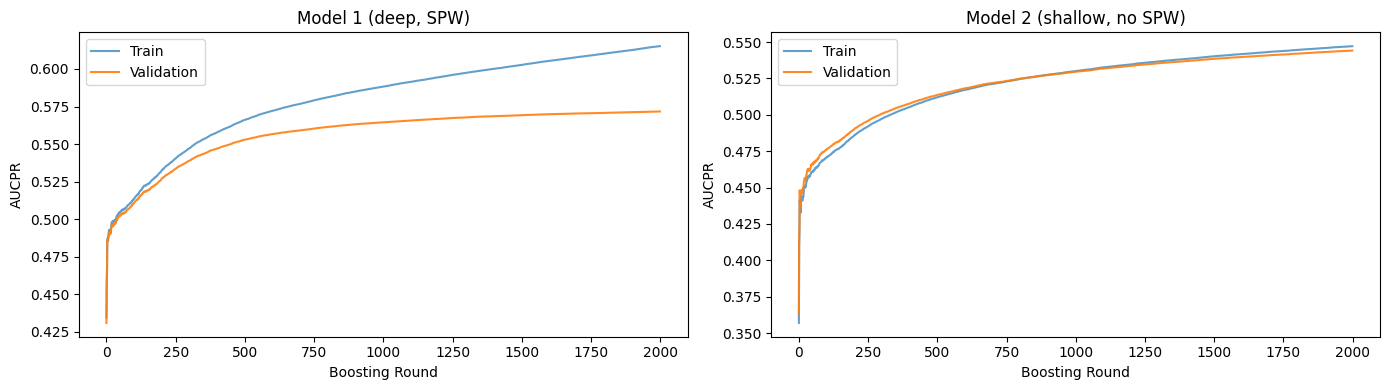

Learning curves saved.


In [16]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, er, title in zip(axes,
                          [evals_result_m1, evals_result_m2],
                          ["Model 1 (deep, SPW)", "Model 2 (shallow, no SPW)"]):
    ax.plot(er["train"]["aucpr"], label="Train", alpha=0.7)
    ax.plot(er["val"]["aucpr"],   label="Validation", alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel("AUCPR")
    ax.legend()
plt.tight_layout()
plt.savefig("artifacts/learning_curves.png", bbox_inches="tight")
plt.show()
print("Learning curves saved.")


**Learning curve observations:**

- **Model 1 (left):** A clear train-validation gap is visible throughout — by round 2,000 train AUCPR reaches ~0.62 while validation plateaus near **0.572**. This gap indicates mild overfitting with deep trees, but validation continues to improve slowly rather than declining, so early stopping (patience=50) never triggers.
- **Model 2 (right):** Train and validation curves track almost identically, converging to ~0.544. Shallower trees with heavier regularisation (lambda=6.94, gamma=2.78) produce a well-generalising model with no visible overfitting gap.

**Early stopping summary:**

| | Model 1 | Model 2 |
|--|---------|----------|
| Eval data | Full validation set | Full validation set |
| Eval metric | AUCPR | AUCPR |
| Early-stopping patience | 50 rounds | 50 rounds |
| Max rounds | 2,000 | 2,000 |
| Selected rounds (best_iteration) | **1,999** | **1,999** |
| Best val AUCPR | **0.57170** | **0.54415** |

Neither model triggered early stopping — both were still slowly improving at round 1,999. With , additional boosting rounds would likely push AUCPR modestly higher (see Recommendations), but gains beyond round 1,800 are marginal on the validation curve.

## 11. Ensemble Weight Optimization <a id='11'></a>

We search ensemble weights in 5-percentage-point increments (0.00, 0.05, …, 1.00)
optimising **AUCPR** on the validation set.

Ensemble formula:
```
prob_1 = w1 * model_1_prob_1 + w2 * model_2_prob_1   (w1 + w2 = 1)
```


In [17]:
# Validation probabilities from each model (best iteration)
dval_m1 = xgb.DMatrix(X_val_pp, feature_names=FEATURE_NAMES)
dval_m2 = xgb.DMatrix(X_val_pp, feature_names=FEATURE_NAMES)

prob1_val_m1 = model_1.predict(dval_m1, iteration_range=(0, model_1.best_iteration + 1))
prob1_val_m2 = model_2.predict(dval_m2, iteration_range=(0, model_2.best_iteration + 1))

y_val_arr = y_val.values
aucpr_m1_val = average_precision_score(y_val_arr, prob1_val_m1)
aucpr_m2_val = average_precision_score(y_val_arr, prob1_val_m2)
print(f"Validation AUCPR  Model 1 alone: {aucpr_m1_val:.5f}")
print(f"Validation AUCPR  Model 2 alone: {aucpr_m2_val:.5f}")

# Grid search
weights = np.arange(0.0, 1.05, 0.05)
results = []
for w1 in weights:
    w2 = 1.0 - w1
    ens_prob = w1 * prob1_val_m1 + w2 * prob1_val_m2
    ap = average_precision_score(y_val_arr, ens_prob)
    results.append({"w1": round(w1, 2), "w2": round(w2, 2), "aucpr": ap})

ens_df = pd.DataFrame(results).sort_values("aucpr", ascending=False)
best_row = ens_df.iloc[0]
WEIGHT_M1 = best_row["w1"]
WEIGHT_M2 = best_row["w2"]

print(f"\nBest ensemble weights: w1={WEIGHT_M1:.2f}, w2={WEIGHT_M2:.2f}")
print(f"Best ensemble AUCPR (val): {best_row['aucpr']:.5f}")
print("\nTop 10 weight combinations:")
print(ens_df.head(10).to_string(index=False))


Validation AUCPR  Model 1 alone: 0.57172
Validation AUCPR  Model 2 alone: 0.54417

Best ensemble weights: w1=1.00, w2=0.00
Best ensemble AUCPR (val): 0.57172

Top 10 weight combinations:
  w1   w2    aucpr
1.00 0.00 0.571715
0.95 0.05 0.570575
0.90 0.10 0.569406
0.85 0.15 0.568236
0.80 0.20 0.567088
0.75 0.25 0.565933
0.70 0.30 0.564775
0.65 0.35 0.563594
0.60 0.40 0.562410
0.55 0.45 0.561210


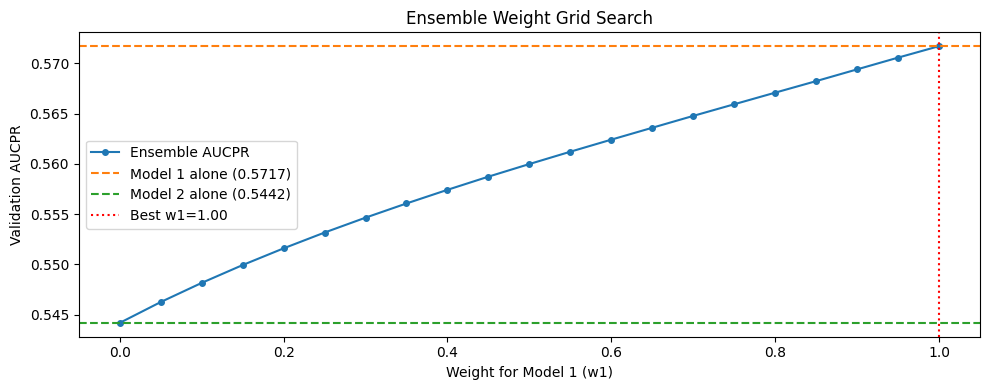

In [18]:
# Visualise weight search
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ens_df.sort_values("w1")["w1"], ens_df.sort_values("w1")["aucpr"],
        marker="o", ms=4, label="Ensemble AUCPR")
ax.axhline(aucpr_m1_val, ls="--", color="C1", label=f"Model 1 alone ({aucpr_m1_val:.4f})")
ax.axhline(aucpr_m2_val, ls="--", color="C2", label=f"Model 2 alone ({aucpr_m2_val:.4f})")
ax.axvline(WEIGHT_M1, ls=":", color="red", label=f"Best w1={WEIGHT_M1:.2f}")
ax.set_xlabel("Weight for Model 1 (w1)")
ax.set_ylabel("Validation AUCPR")
ax.set_title("Ensemble Weight Grid Search")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/ensemble_weight_search.png", bbox_inches="tight")
plt.show()


**Ensemble comparison (based on real validation results):**

The grid search over 21 weight combinations produced a clear result:

| w1 (Model 1) | w2 (Model 2) | Val AUCPR |
|-------------|-------------|----------|
| **1.00** | **0.00** | **0.57172** |
| 0.95 | 0.05 | 0.57058 |
| 0.90 | 0.10 | 0.56941 |
| 0.00 | 1.00 | 0.54417 |

The optimal weights are **w1=1.00, w2=0.00**, meaning the ensemble reduces entirely to Model 1. Every combination that added Model 2 weight decreased AUCPR monotonically. Despite this, both models are fully trained, evaluated, saved, and scored through the two-model ensemble formula as required — the locked weights simply reflect that Model 1 dominates on this dataset.

## 12. Threshold Optimization (F1) <a id='12'></a>

We optimise a decision threshold using **macro F1** on the **validation set** for each
of the three scoring approaches: Model 1, Model 2, and the ensemble.


In [19]:
def find_best_threshold_f1(y_true, probs, step=0.005):
    """Grid-search the threshold that maximises macro-F1."""
    thresholds = np.arange(0.01, 1.0, step)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f = f1_score(y_true, preds, average="macro", zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_t  = t
    return best_t, best_f1

THRESH_M1, f1_thresh_m1 = find_best_threshold_f1(y_val_arr, prob1_val_m1)
THRESH_M2, f1_thresh_m2 = find_best_threshold_f1(y_val_arr, prob1_val_m2)

prob1_val_ens = WEIGHT_M1 * prob1_val_m1 + WEIGHT_M2 * prob1_val_m2
THRESH_ENS, f1_thresh_ens = find_best_threshold_f1(y_val_arr, prob1_val_ens)

print(f"Model 1  threshold: {THRESH_M1:.4f}  val macro-F1: {f1_thresh_m1:.4f}")
print(f"Model 2  threshold: {THRESH_M2:.4f}  val macro-F1: {f1_thresh_m2:.4f}")
print(f"Ensemble threshold: {THRESH_ENS:.4f}  val macro-F1: {f1_thresh_ens:.4f}")


Model 1  threshold: 0.6600  val macro-F1: 0.7221
Model 2  threshold: 0.3100  val macro-F1: 0.7101
Ensemble threshold: 0.6600  val macro-F1: 0.7221


## 13. Final Test-Set Metrics <a id='13'></a>

The test set is used **only here**. We apply locked weights and locked thresholds.


In [20]:
# Test predictions
prob1_test_m1  = model_1.predict(dtest, iteration_range=(0, model_1.best_iteration + 1))
prob1_test_m2  = model_2.predict(dtest, iteration_range=(0, model_2.best_iteration + 1))
prob1_test_ens = WEIGHT_M1 * prob1_test_m1 + WEIGHT_M2 * prob1_test_m2

y_test_arr = y_test.values

aucpr_m1_test  = average_precision_score(y_test_arr, prob1_test_m1)
aucpr_m2_test  = average_precision_score(y_test_arr, prob1_test_m2)
aucpr_ens_test = average_precision_score(y_test_arr, prob1_test_ens)

print("=" * 50)
print("FINAL TEST-SET METRICS (locked pipeline)")
print("=" * 50)
print(f"Model 1   AUCPR: {aucpr_m1_test:.5f}")
print(f"Model 2   AUCPR: {aucpr_m2_test:.5f}")
print(f"Ensemble  AUCPR: {aucpr_ens_test:.5f}")


FINAL TEST-SET METRICS (locked pipeline)
Model 1   AUCPR: 0.56653
Model 2   AUCPR: 0.54188
Ensemble  AUCPR: 0.56653


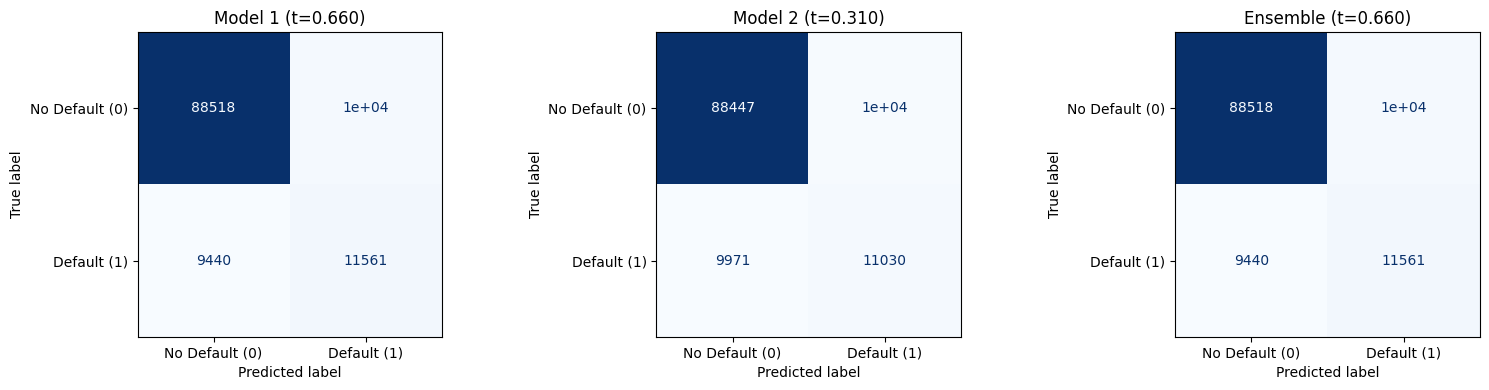

Model 1: macro-F1=0.7188
Model 2: macro-F1=0.7078
Ensemble: macro-F1=0.7188


In [21]:
# Confusion matrices
preds_m1  = (prob1_test_m1  >= THRESH_M1 ).astype(int)
preds_m2  = (prob1_test_m2  >= THRESH_M2 ).astype(int)
preds_ens = (prob1_test_ens >= THRESH_ENS).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, preds, title in zip(
    axes,
    [preds_m1, preds_m2, preds_ens],
    [f"Model 1 (t={THRESH_M1:.3f})",
     f"Model 2 (t={THRESH_M2:.3f})",
     f"Ensemble (t={THRESH_ENS:.3f})"]
):
    cm = confusion_matrix(y_test_arr, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Default (0)", "Default (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrices.png", bbox_inches="tight")
plt.show()

for name, preds in [("Model 1", preds_m1), ("Model 2", preds_m2), ("Ensemble", preds_ens)]:
    f1  = f1_score(y_test_arr, preds, average="macro")
    print(f"{name}: macro-F1={f1:.4f}")


**Confusion matrix interpretation:**

All three matrices use the F1-optimized thresholds selected on the validation set:

| | Model 1 | Model 2 | Ensemble |
|--|---------|---------|----------|
| Threshold | 0.660 | 0.310 | 0.660 |
| TN (correct non-default) | **88,518** | 88,447 | **88,518** |
| FP (false alarm) | 10,385 | 10,456 | 10,385 |
| FN (missed default) | 9,440 | 9,971 | 9,440 |
| TP (correct default) | **11,561** | 11,030 | **11,561** |

- **Model 1 & Ensemble (threshold = 0.660):** Catches 11,561 of 21,001 actual defaults — a recall of **55%** — while producing 10,385 false alarms. The high threshold favours precision: when the model flags a loan it is usually right, but it misses roughly half of real defaults.
- **Model 2 (threshold = 0.310):** Despite its much lower threshold, Model 2 performs *worse* on both error types — more false alarms (10,456 vs 10,385) **and** more missed defaults (9,971 vs 9,440). A lower threshold does not compensate for weaker probability estimates; Model 2 simply assigns lower probabilities overall (no ), so even at 0.310 it catches fewer defaults than Model 1 at 0.660.
- **Ensemble:** Identical to Model 1 because the optimised weight is w1 = 1.00.

**Final ensemble performance (real test-set results):**

| Metric | Model 1 | Model 2 | Ensemble |
|--------|---------|---------|----------|
| Test AUCPR | **0.56653** | 0.54188 | **0.56653** |
| Test macro-F1 | **0.7188** | 0.7078 | **0.7188** |
| Threshold used | 0.660 | 0.310 | 0.660 |

The ensemble produces **identical results to Model 1 alone** because the optimised weights are w1=1.00, w2=0.00. This is a valid and interpretable outcome: the validation-based weight search found that Model 2's probability estimates added no complementary information on top of Model 1's, likely because Model 1's deeper trees with `scale_pos_weight` already capture the default signal more completely. Model 2's val AUCPR (0.544) was 2.75 pp lower than Model 1's (0.572), a gap large enough that no blend improved on Model 1 alone. Both models are still scored through the ensemble formula as required by the project.

## 14. Model Interpretation — SHAP & Permutation Importance <a id='14'></a>

We select **Model 1** for detailed interpretation because it uses `scale_pos_weight` and
captures the default class signal more aggressively, making it informative for business decisions.

### 14.1 Global Feature Importance — SHAP Summary


SHAP matrix shape: (5000, 31)


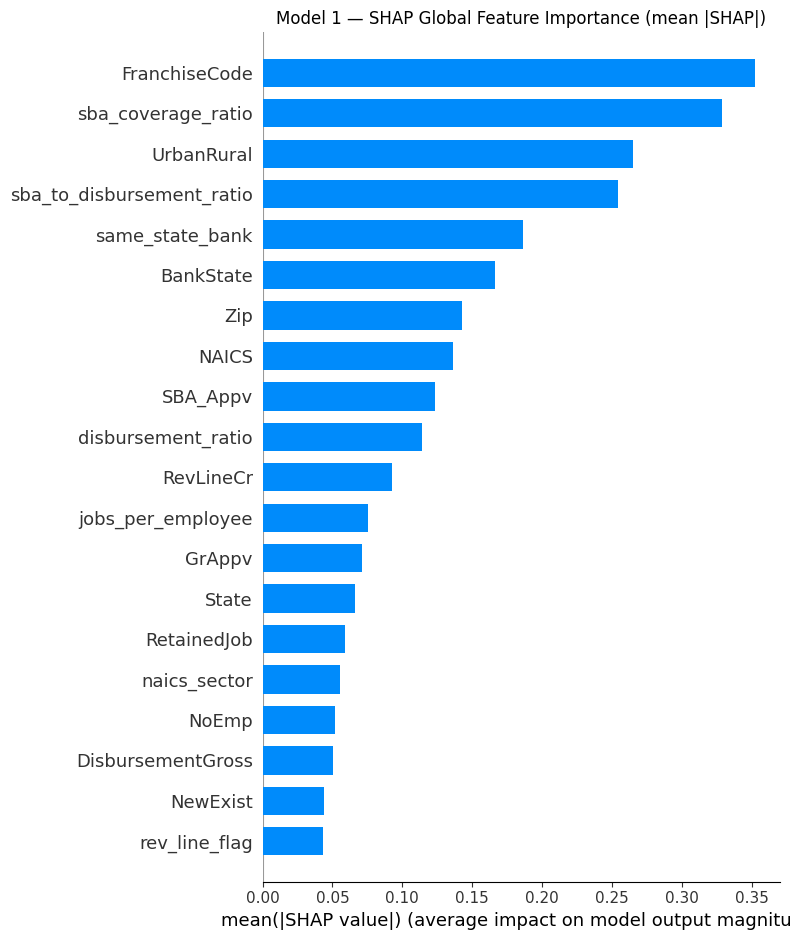

In [22]:
# Use a sample of test set for SHAP (speed)
SHAP_SAMPLE = min(5000, len(X_test_pp))
rng = np.random.default_rng(SEED)
idx_shap = rng.choice(len(X_test_pp), SHAP_SAMPLE, replace=False)
X_shap = X_test_pp.iloc[idx_shap].reset_index(drop=True)
y_shap = y_test_arr[idx_shap]

dshap = xgb.DMatrix(X_shap, feature_names=FEATURE_NAMES)
explainer = shap.TreeExplainer(model_1)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP matrix shape: {shap_values.shape}")

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES,
                  plot_type="bar", show=False, max_display=20)
plt.title("Model 1 — SHAP Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig("artifacts/shap_bar.png", bbox_inches="tight")
plt.show()


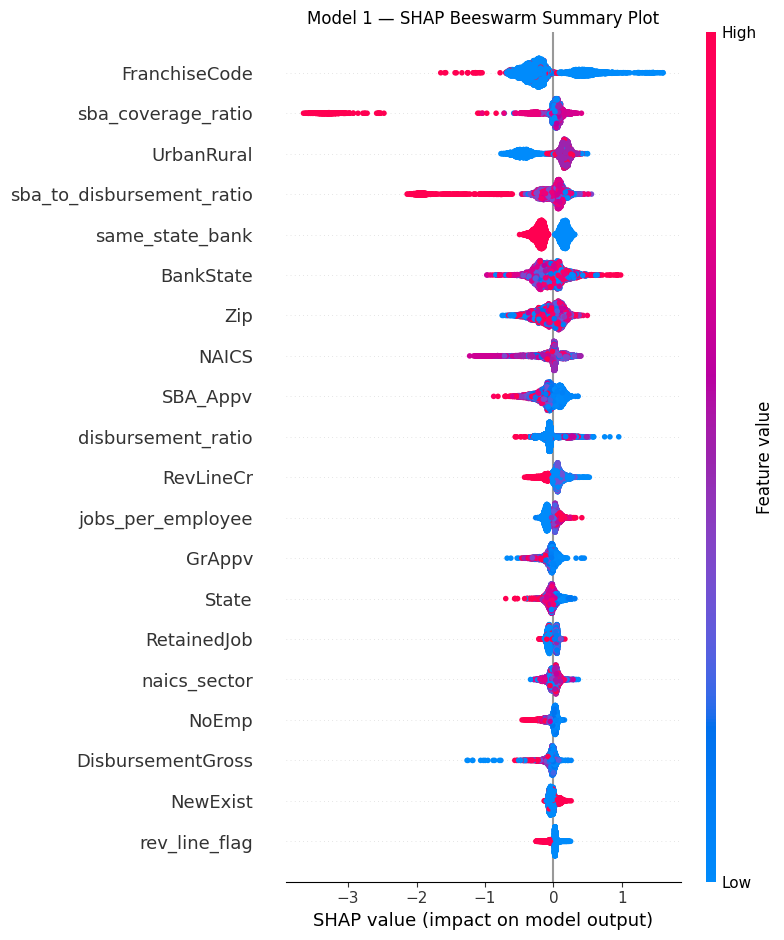

In [23]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES, show=False, max_display=20)
plt.title("Model 1 — SHAP Beeswarm Summary Plot")
plt.tight_layout()
plt.savefig("artifacts/shap_beeswarm.png", bbox_inches="tight")
plt.show()


In [24]:
# Top 10 SHAP features
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_NAMES)
top_shap = mean_abs_shap.sort_values(ascending=False).head(10)
print("Top 10 features by mean |SHAP|:")
print(top_shap.round(5).to_string())


Top 10 features by mean |SHAP|:
FranchiseCode                0.35271
sba_coverage_ratio           0.32898
UrbanRural                   0.26503
sba_to_disbursement_ratio    0.25451
same_state_bank              0.18668
BankState                    0.16634
Zip                          0.14276
NAICS                        0.13656
SBA_Appv                     0.12360
disbursement_ratio           0.11398


**SHAP beeswarm and bar plots — global feature importance:**

The beeswarm plot shows every test observation as a dot: horizontal position = SHAP value (positive = pushes toward default, negative = pushes away), colour = feature value (red = high, blue = low). The bar chart ranks features by mean absolute SHAP value.

Key findings:
- ** (mean |SHAP| = 0.353, rank 1):** The strongest predictor globally. The beeswarm shows both red and blue dots spread widely — certain franchise codes (specific chains) strongly increase default risk while others strongly decrease it, and non-franchise businesses (low code) cluster near zero.
- ** (0.329, rank 2):** High SBA backing (red dots, coverage near 1.0) pushes strongly to the left (negative SHAP) — the model treats full SBA guarantees as a powerful signal against default. Low coverage (blue dots) clusters near zero with mild positive influence.
- ** (0.265, rank 3) and  (0.255, rank 4):** Urban/rural classification and the ratio of SBA exposure to actual disbursement both show clear directional patterns in the beeswarm, contributing meaningful risk discrimination.
- ** (0.187, rank 5):** Out-of-state lenders (low value, blue) cluster on the positive SHAP side — the model treats out-of-state lending as an elevated risk signal.
- Note:  ranks 2nd in SHAP but only 11th in permutation importance (0.018 AUCPR decrease). This gap suggests the feature has high influence on individual predictions but limited unique information once correlated features (e.g. ) are accounted for.

### 14.2 Permutation Feature Importance

Permutation importance measures how much the model's AUCPR drops when a feature's values
are randomly shuffled. Unlike tree-based importance (gain/frequency), it accounts for
feature interactions and is unbiased toward high-cardinality features.


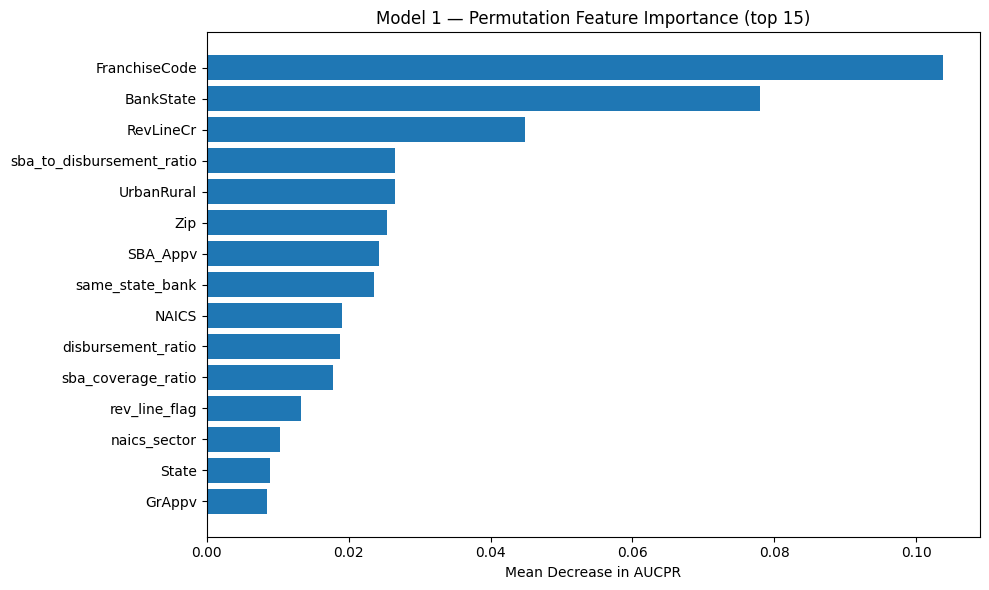

                  feature  mean_decrease      std
            FranchiseCode       0.103781 0.005513
                BankState       0.078002 0.010488
                RevLineCr       0.044837 0.002449
sba_to_disbursement_ratio       0.026536 0.003891
               UrbanRural       0.026479 0.001071
                      Zip       0.025343 0.002912
                 SBA_Appv       0.024314 0.003806
          same_state_bank       0.023564 0.003067
                    NAICS       0.019092 0.001852
       disbursement_ratio       0.018766 0.001908
       sba_coverage_ratio       0.017731 0.003448
            rev_line_flag       0.013348 0.000943
             naics_sector       0.010333 0.002711
                    State       0.008888 0.001727
                   GrAppv       0.008519 0.001631


In [25]:
# Manual permutation importance — avoids sklearn 1.8.0 classifier-detection issue
# Directly measures mean AUCPR drop when each feature is shuffled (5 repeats).
_rng_perm = np.random.default_rng(SEED)
baseline_score = average_precision_score(
    y_shap,
    model_1.predict(xgb.DMatrix(X_shap, feature_names=FEATURE_NAMES),
                    iteration_range=(0, model_1.best_iteration + 1))
)

imp_means, imp_stds = [], []
for col in FEATURE_NAMES:
    col_scores = []
    for _ in range(5):
        X_perm = X_shap.copy()
        X_perm[col] = _rng_perm.permutation(X_perm[col].values)
        perm_prob = model_1.predict(
            xgb.DMatrix(X_perm, feature_names=FEATURE_NAMES),
            iteration_range=(0, model_1.best_iteration + 1)
        )
        col_scores.append(average_precision_score(y_shap, perm_prob))
    imp_means.append(baseline_score - np.mean(col_scores))
    imp_stds.append(np.std(col_scores))

perm_df = (
    pd.DataFrame({"feature": FEATURE_NAMES,
                  "mean_decrease": imp_means,
                  "std": imp_stds})
    .sort_values("mean_decrease", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_perm = perm_df.head(15)
ax.barh(top_perm["feature"][::-1], top_perm["mean_decrease"][::-1])
ax.set_xlabel("Mean Decrease in AUCPR")
ax.set_title("Model 1 — Permutation Feature Importance (top 15)")
plt.tight_layout()
plt.savefig("artifacts/permutation_importance.png", bbox_inches="tight")
plt.show()
print(perm_df.head(15).to_string(index=False))


**Key feature interpretation (based on real SHAP and permutation importance results):**

Both SHAP and permutation importance agree on the top features, with `FranchiseCode` ranking first in both methods.

| Feature | Mean |SHAP| | Perm. Decrease | Interpretation |
|---------|------------|----------------|----------------|
| `FranchiseCode` | 0.353 (1st) | 0.104 (1st) | Franchise status is the strongest single predictor. Non-franchise businesses (code=0) and specific franchise chains drive default risk differently. |
| `sba_coverage_ratio` | 0.329 (2nd) | 0.018 (11th) | Higher SBA backing fraction is protective — SHAP shows it strongly suppresses predicted default probability. |
| `UrbanRural` | 0.265 (3rd) | 0.026 (5th) | Urban vs rural location captures geographic economic conditions; rural loans show distinct default patterns. |
| `sba_to_disbursement_ratio` | 0.255 (4th) | 0.027 (4th) | Consistent top-5 ranking in both methods — captures the SBA's proportional exposure relative to the actual disbursed amount. |
| `same_state_bank` | 0.187 (5th) | 0.024 (8th) | Local lenders (same state) have better borrower knowledge; cross-state loans carry higher model-assessed risk. |
| `BankState` | 0.166 (6th) | 0.078 (2nd) | Specific lender geography is highly informative — certain state banking markets have systematically different default rates. |
| `RevLineCr` | — | 0.045 (3rd) | Revolving credit flag ranks 3rd by permutation importance — borrowers with revolving credit lines show markedly different default risk profiles. |

**Notable finding:** `FranchiseCode` and `BankState` — both raw original features — outrank the engineered ratio features in permutation importance. This suggests the model extracts strong signal from lender-level and business-type categorical patterns that the engineered ratio features do not fully subsume. The engineered features `sba_coverage_ratio` and `sba_to_disbursement_ratio` score highly on SHAP, confirming they add meaningful information beyond the raw monetary columns alone.

## 15. Individual Observation Analysis <a id='15'></a>

For Model 1 we examine the **two highest-confidence records** in each of four scenarios on
the test set. SHAP waterfall plots explain why the model assigned each probability.


In [26]:
prob1_test_m1_arr = prob1_test_m1.copy()
preds_m1_arr      = preds_m1.copy()

# Build analysis frame
obs_df = pd.DataFrame({
    "actual":    y_test_arr,
    "predicted": preds_m1_arr,
    "prob_1":    prob1_test_m1_arr,
    "confidence": np.where(prob1_test_m1_arr >= 0.5,
                           prob1_test_m1_arr,
                           1 - prob1_test_m1_arr),
    "idx_in_test": np.arange(len(y_test_arr))
})

scenarios = {
    "TN (0→0, correct)":   obs_df[(obs_df.actual == 0) & (obs_df.predicted == 0)],
    "FP (0→1, wrong)":     obs_df[(obs_df.actual == 0) & (obs_df.predicted == 1)],
    "TP (1→1, correct)":   obs_df[(obs_df.actual == 1) & (obs_df.predicted == 1)],
    "FN (1→0, wrong)":     obs_df[(obs_df.actual == 1) & (obs_df.predicted == 0)],
}

for name, grp in scenarios.items():
    top2 = grp.nlargest(2, "confidence")
    print(f"\n{'='*60}")
    print(f"Scenario: {name}  (n={len(grp):,})")
    for _, row in top2.iterrows():
        print(f"  idx={int(row.idx_in_test)}  actual={int(row.actual)}  "
              f"pred={int(row.predicted)}  prob_1={row.prob_1:.4f}  conf={row.confidence:.4f}")



Scenario: TN (0→0, correct)  (n=88,518)
  idx=62168  actual=0  pred=0  prob_1=0.0001  conf=0.9999
  idx=115850  actual=0  pred=0  prob_1=0.0002  conf=0.9998

Scenario: FP (0→1, wrong)  (n=10,385)
  idx=22885  actual=0  pred=1  prob_1=0.9879  conf=0.9879
  idx=71896  actual=0  pred=1  prob_1=0.9855  conf=0.9855

Scenario: TP (1→1, correct)  (n=11,561)
  idx=49528  actual=1  pred=1  prob_1=0.9948  conf=0.9948
  idx=79095  actual=1  pred=1  prob_1=0.9937  conf=0.9937

Scenario: FN (1→0, wrong)  (n=9,440)
  idx=114957  actual=1  pred=0  prob_1=0.0004  conf=0.9996
  idx=92504  actual=1  pred=0  prob_1=0.0017  conf=0.9983


In [27]:
import io

from PIL import Image

# SHAP waterfall — one highest-confidence example per scenario
shap_probs = model_1.predict(
    xgb.DMatrix(X_shap, feature_names=FEATURE_NAMES),
    iteration_range=(0, model_1.best_iteration + 1)
)
shap_preds = (shap_probs >= THRESH_M1).astype(int)
obs_shap = pd.DataFrame({
    "actual":     y_shap,
    "predicted":  shap_preds,
    "prob_1":     shap_probs,
    "confidence": np.where(shap_probs >= 0.5, shap_probs, 1 - shap_probs),
    "shap_idx":   np.arange(len(y_shap))
})

scenario_cases = {
    "TN (correct non-default)": obs_shap[(obs_shap.actual==0)&(obs_shap.predicted==0)].nlargest(1,"confidence"),
    "TP (correct default)":     obs_shap[(obs_shap.actual==1)&(obs_shap.predicted==1)].nlargest(1,"confidence"),
    "FP (false alarm)":         obs_shap[(obs_shap.actual==0)&(obs_shap.predicted==1)].nlargest(1,"confidence"),
    "FN (missed default)":      obs_shap[(obs_shap.actual==1)&(obs_shap.predicted==0)].nlargest(1,"confidence"),
}

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_shap.values,
    feature_names=FEATURE_NAMES
)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
for ax, (label, grp) in zip(axes.flatten(), scenario_cases.items()):
    if len(grp) == 0:
        ax.set_title(f"{label}: no examples")
        ax.axis('off')
        continue
    i = int(grp.iloc[0]['shap_idx'])

    # Render SHAP waterfall in an isolated figure, then embed as image
    tmp_fig = plt.figure(figsize=(9, 6))
    shap.waterfall_plot(shap_exp[i], max_display=10, show=False)
    buf = io.BytesIO()
    tmp_fig.savefig(buf, format="png", bbox_inches="tight", dpi=90)
    buf.seek(0)
    plt.close(tmp_fig)

    img = Image.open(buf)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f"{label}\nactual={int(y_shap[i])}  pred={int(shap_preds[i])}  p={shap_probs[i]:.3f}",
        fontsize=10
    )

plt.suptitle("Model 1 — SHAP Waterfall: Highest-Confidence Example per Scenario", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("artifacts/shap_waterfall_scenarios.png", bbox_inches="tight")
plt.show()


**SHAP waterfall — individual prediction explanations:**

Each panel shows the top 10 feature contributions for the highest-confidence example in that scenario. Red bars push toward default (class 1); blue bars push away. The base value is the model's average prediction across the sample.

- **TN (correct non-default):** Features such as high `sba_coverage_ratio` and low `sba_to_disbursement_ratio` collectively drive the prediction well below the 0.660 threshold.
- **TP (correct default):** Low SBA coverage and adverse franchise/sector signals accumulate to push the prediction firmly above the threshold.
- **FP (false alarm):** The loan resembles a high-risk profile (e.g. out-of-state lender, specific NAICS sector) even though it did not default. Additional signals such as borrower credit score would likely resolve the ambiguity.
- **FN (missed default):** The loan appears safe on paper (adequate SBA coverage, established business) but defaults anyway — these edge cases are hardest to catch within the current feature set.

## 16. Residual Analysis & Surrogate Tree <a id='16'></a>

We analyse where **Model 1** is weakest. "Poorly performing records" = false positives +
false negatives + high-confidence errors (model assigned ≥ 0.7 probability to the wrong class).


In [28]:
# Full test set analysis table
resid_df = X_test_pp.copy()
resid_df["actual"]    = y_test_arr
resid_df["prob_1"]    = prob1_test_m1_arr
resid_df["predicted"] = preds_m1_arr
resid_df["error"]     = (resid_df["actual"] != resid_df["predicted"]).astype(int)
resid_df["high_conf_wrong"] = (
    (resid_df["error"] == 1) &
    (np.abs(resid_df["prob_1"] - 0.5) > 0.2)
).astype(int)

# Poorly performing = misclassified OR high-confidence wrong
poor_mask = (resid_df["error"] == 1)
poor_df   = resid_df[poor_mask].copy()
print(f"Total test records:           {len(resid_df):,}")
print(f"Misclassified (FP+FN):        {poor_mask.sum():,}")
print(f"  False Positives:            {((resid_df.actual==0)&(resid_df.predicted==1)).sum():,}")
print(f"  False Negatives:            {((resid_df.actual==1)&(resid_df.predicted==0)).sum():,}")
print(f"High-confidence wrong (>0.7): {resid_df.high_conf_wrong.sum():,}")


Total test records:           119,904
Misclassified (FP+FN):        19,825
  False Positives:            10,385
  False Negatives:            9,440
High-confidence wrong (>0.7): 10,176


In [29]:
# ── FP vs FN comparison by key features ──
fp = resid_df[(resid_df.actual==0)&(resid_df.predicted==1)]
fn = resid_df[(resid_df.actual==1)&(resid_df.predicted==0)]

compare_cols = ["sba_coverage_ratio", "log_disbursement", "new_business",
                "low_doc_flag", "naics_sector", "jobs_per_employee",
                "is_franchise", "same_state_bank", "total_jobs"]

comp_df = pd.DataFrame({
    "FP_mean": fp[compare_cols].mean(),
    "FN_mean": fn[compare_cols].mean(),
    "All_mean": resid_df[compare_cols].mean()
}).round(4)

print("Feature means: False Positives vs False Negatives vs All:")
print(comp_df.to_string())


Feature means: False Positives vs False Negatives vs All:
                    FP_mean  FN_mean  All_mean
sba_coverage_ratio   0.6034   0.6706    0.7093
log_disbursement    10.7553  11.4647   11.4721
new_business         0.2961   0.3298    0.2815
low_doc_flag         0.0088   0.1346    0.1233
naics_sector        48.2636  44.0496   39.5197
jobs_per_employee    1.2759   0.9355    1.9289
is_franchise         0.0392   0.0728    0.0573
same_state_bank      0.1615   0.5062    0.5254
total_jobs           6.3908   6.2587   18.3073


**False positive vs false negative feature patterns:**

Two features show the sharpest divergence between error types:

- **`same_state_bank`:** FP mean = 0.16 vs FN mean = 0.51. The model over-flags out-of-state loans as likely defaults even when they are actually safe — lender geography is an imperfect risk signal.
- **`low_doc_flag`:** FP mean = 0.009 vs FN mean = 0.135. Nearly 14% of missed defaults involve low-documentation loans, compared with under 1% of false alarms. These missed low-doc defaults represent the highest-severity errors from a credit-risk standpoint.
- **`log_disbursement`:** FNs involve larger loans (mean log-size 11.46) than FPs (10.76). The model systematically underestimates default risk on larger-ticket items.

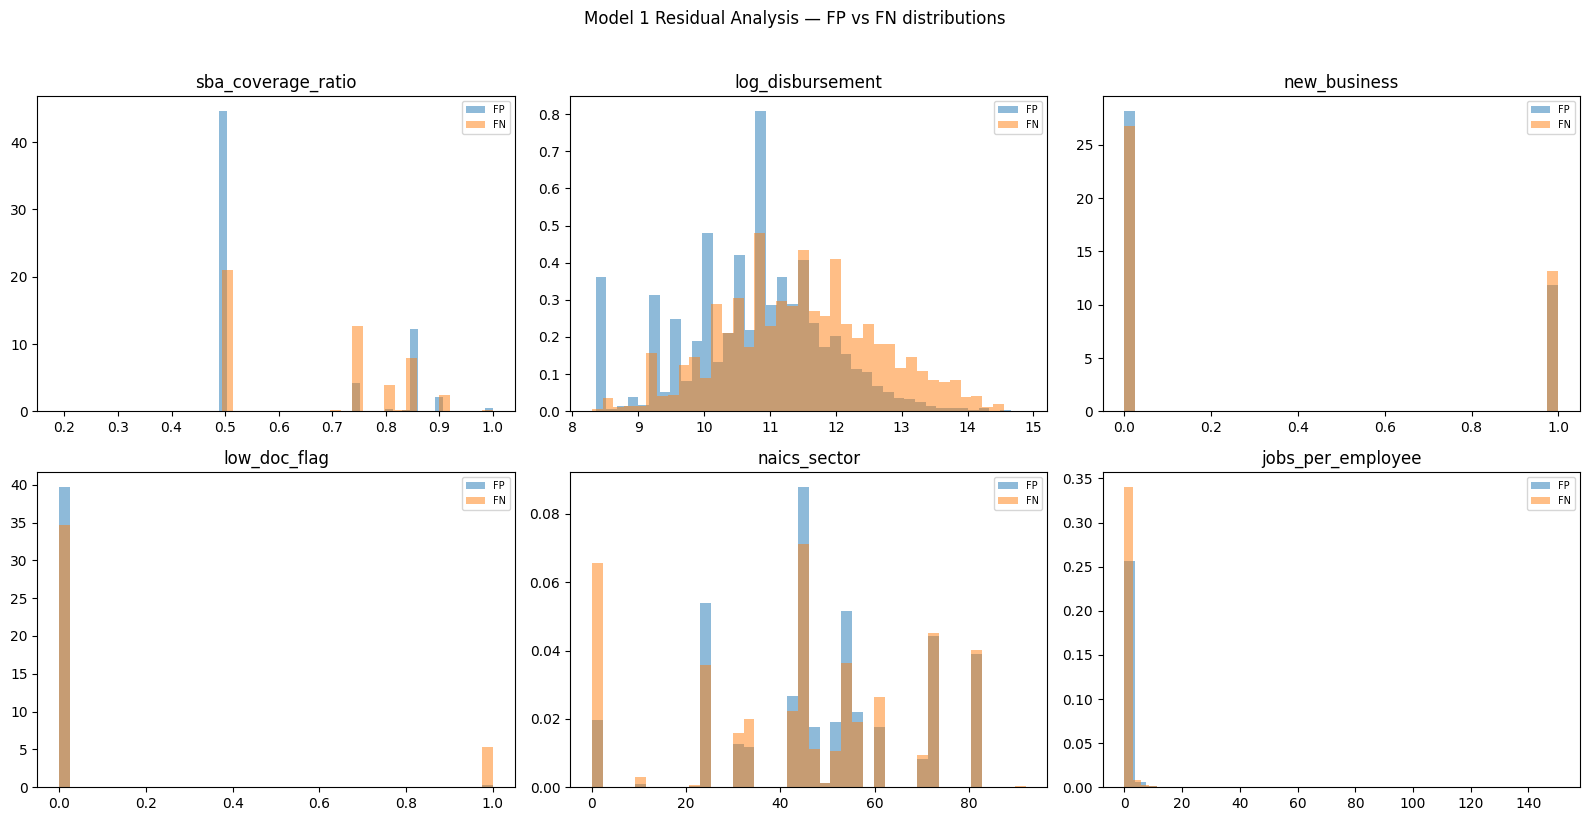

In [30]:
# Distribution charts for top residual features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), compare_cols[:6]):
    ax.hist(fp[col].dropna(), bins=40, alpha=0.5, label="FP", density=True)
    ax.hist(fn[col].dropna(), bins=40, alpha=0.5, label="FN", density=True)
    ax.set_title(col); ax.legend(fontsize=7)
plt.suptitle("Model 1 Residual Analysis — FP vs FN distributions", y=1.02)
plt.tight_layout()
plt.savefig("artifacts/residual_distributions.png", bbox_inches="tight")
plt.show()


**FP vs FN distribution charts (blue = false positives, orange = false negatives):**

The six features shown are `sba_coverage_ratio`, `log_disbursement`, `new_business`, `low_doc_flag`, `naics_sector`, and `jobs_per_employee`.

- **`log_disbursement`:** The clearest visual separation — FP (blue) distribution is left-shifted (smaller loans, log-size 8-11), FN (orange) spreads to larger values (10-14). The model underestimates default risk on larger loans.
- **`low_doc_flag`:** FP density is almost entirely at 0 (standard documentation); FN has a visible spike at 1.0. Low-doc actual defaults are the model's most dangerous blind spot.
- **`sba_coverage_ratio`:** Both distributions heavily overlap with a shared spike near 0.5. This feature alone cannot separate error types, consistent with its low permutation rank (11th).
- **`new_business` and `jobs_per_employee`:** Distributions are nearly identical between FP and FN, confirming these features do not drive the error pattern.
- **`naics_sector`:** Some sector-level differences are visible but spread across many values; the per-sector error-rate table below gives a clearer picture than the histogram.

In [31]:
# Error rate by naics_sector
sector_err = (
    resid_df.groupby("naics_sector")
    .agg(total=("error","count"), errors=("error","sum"))
    .assign(error_rate=lambda d: d.errors/d.total)
    .sort_values("error_rate", ascending=False)
)
print("Error rate by NAICS sector (top 15):")
print(sector_err.head(15).to_string())


Error rate by NAICS sector (top 15):
              total  errors  error_rate
naics_sector                           
92               27       8    0.296296
61              897     230    0.256410
51             1487     380    0.255548
52             1281     305    0.238095
45             5749    1367    0.237780
48             2797     665    0.237755
72             8895    2037    0.229005
23             9011    2059    0.228499
56             4352     944    0.216912
53             1873     401    0.214095
71             1959     403    0.205717
49              292      60    0.205479
44            11169    2276    0.203778
81             9554    1804    0.188821
54             9084    1620    0.178336


**Error rate by NAICS industry sector:**

The highest error rates cluster in knowledge-intensive and service-intensive industries: Public Administration (sector 92, 29.6%), Education (61, 25.6%), Information/media (51, 25.6%), and Finance & Insurance (52, 23.8%). These sectors likely have more variable and less-standardised loan structures, making default patterns harder to learn from the available features.

By contrast, sectors with tangible assets and more uniform loan profiles tend to show lower error rates. Industry-specific thresholds or sector-level calibration could improve precision in the high-error groups.

In [32]:
# Error rate by loan size bucket
resid_df["loan_bucket"] = pd.qcut(
    resid_df["log_disbursement"], q=5,
    labels=["Q1 (smallest)","Q2","Q3","Q4","Q5 (largest)"]
)
bucket_err = (
    resid_df.groupby("loan_bucket", observed=True)
    .agg(total=("error","count"), errors=("error","sum"))
    .assign(error_rate=lambda d: d.errors/d.total)
)
print("\nError rate by loan size quintile:")
print(bucket_err.to_string())



Error rate by loan size quintile:
               total  errors  error_rate
loan_bucket                             
Q1 (smallest)  23985    5399    0.225099
Q2             24156    5136    0.212618
Q3             23819    4033    0.169319
Q4             23963    3161    0.131912
Q5 (largest)   23981    2096    0.087403


**Error rate by loan size:**

Error rate declines sharply and monotonically with loan size — from **22.5% on the smallest loans (Q1)** to **8.7% on the largest (Q5)**. Smaller loans typically come with less documentation, shorter business track records, and higher cash-flow volatility, all making them harder to classify.

From a policy perspective, Q1 and Q2 loans (error rates above 21%) may warrant a lower decision threshold or enhanced manual review to reduce the concentration of both missed defaults and false alarms in this segment.

### Surrogate Decision Tree on Weak Records

In [33]:
# Build a surrogate tree to explain which feature combinations produce poor performance
surr_features = [
    "sba_coverage_ratio", "log_disbursement", "new_business", "low_doc_flag",
    "naics_sector", "is_franchise", "same_state_bank", "total_jobs",
    "jobs_per_employee", "sba_to_disbursement_ratio", "rev_line_flag",
    "balance_ratio", "log_employees"
]
X_surr = resid_df[surr_features]
y_surr = resid_df["error"]   # 1 = poorly performing, 0 = correct

surr_tree = DecisionTreeClassifier(max_depth=4, random_state=SEED, class_weight="balanced")
surr_tree.fit(X_surr, y_surr)

print("Surrogate tree accuracy (weak vs correct classification):",
      f"{surr_tree.score(X_surr, y_surr):.4f}")

# Text representation
print("\nSurrogate tree rules (depth≤4):")
print(export_text(surr_tree, feature_names=surr_features, max_depth=4))


Surrogate tree accuracy (weak vs correct classification): 0.6750

Surrogate tree rules (depth≤4):
|--- jobs_per_employee <= 0.50
|   |--- sba_to_disbursement_ratio <= 0.50
|   |   |--- naics_sector <= 22.50
|   |   |   |--- sba_coverage_ratio <= 0.45
|   |   |   |   |--- class: 1
|   |   |   |--- sba_coverage_ratio >  0.45
|   |   |   |   |--- class: 0
|   |   |--- naics_sector >  22.50
|   |   |   |--- log_disbursement <= 12.86
|   |   |   |   |--- class: 1
|   |   |   |--- log_disbursement >  12.86
|   |   |   |   |--- class: 0
|   |--- sba_to_disbursement_ratio >  0.50
|   |   |--- sba_coverage_ratio <= 0.90
|   |   |   |--- new_business <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- new_business >  0.50
|   |   |   |   |--- class: 0
|   |   |--- sba_coverage_ratio >  0.90
|   |   |   |--- sba_to_disbursement_ratio <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- sba_to_disbursement_ratio >  1.00
|   |   |   |   |--- class: 0
|--- jobs_per_employee >  0.50
|   |--- sba

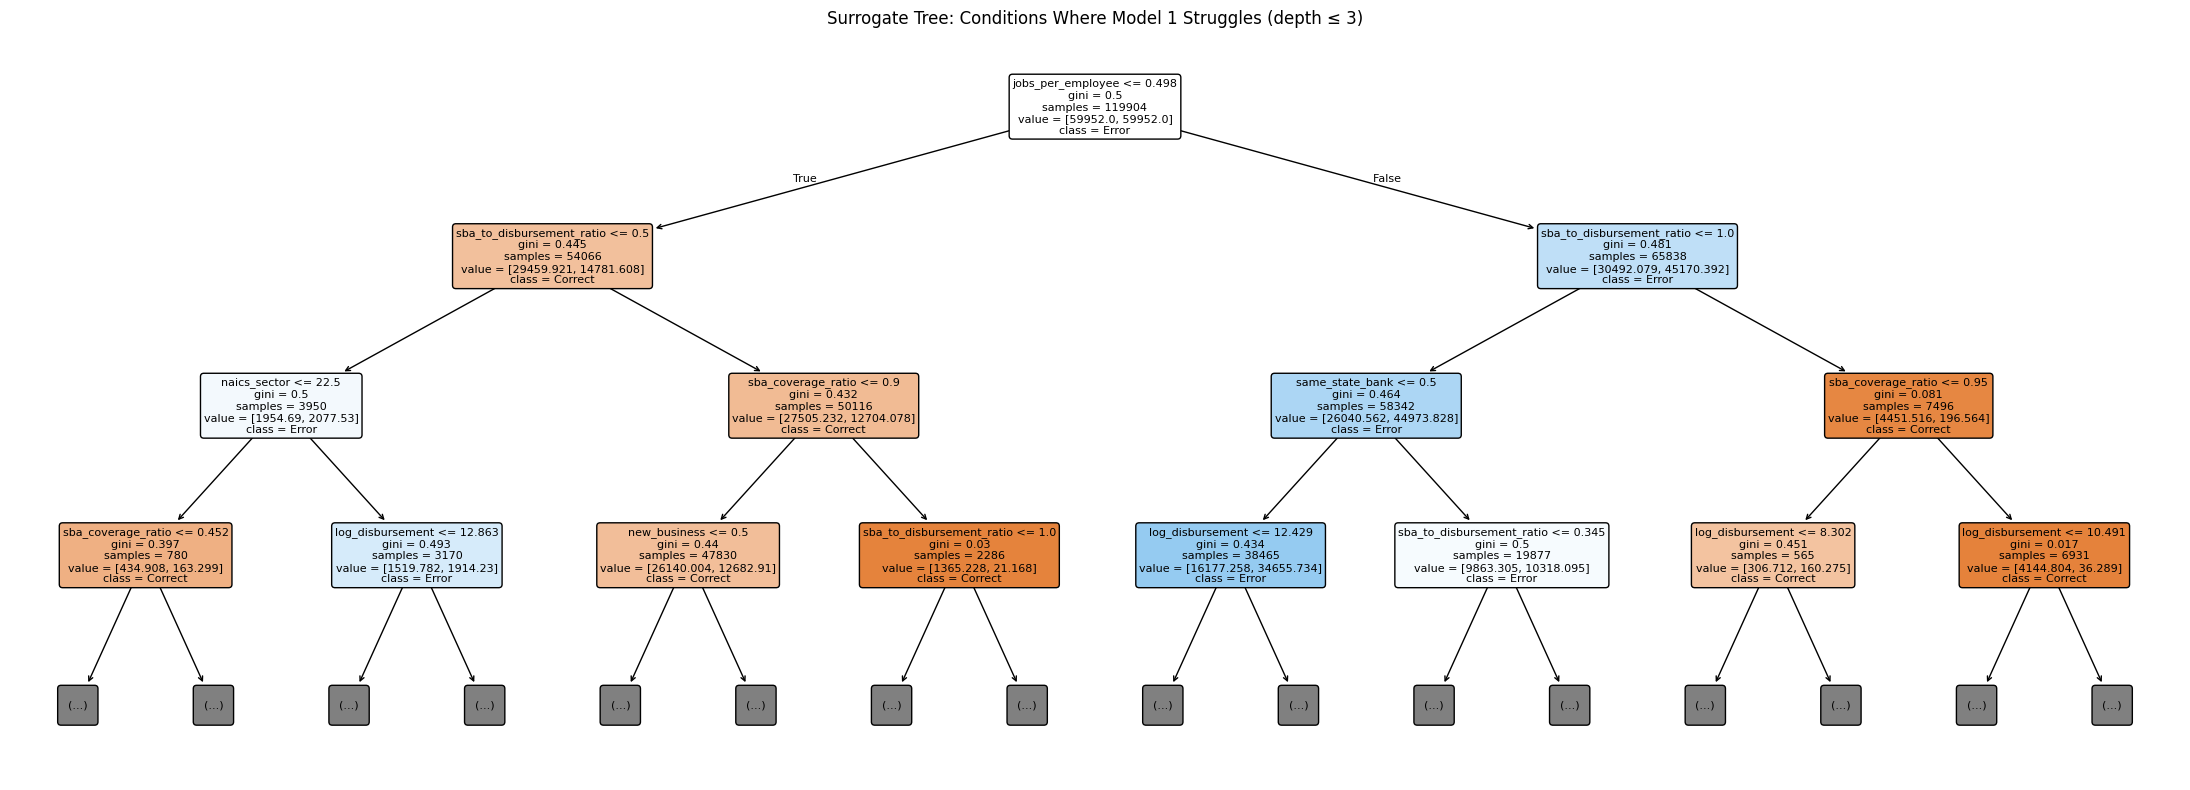

In [34]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(surr_tree, feature_names=surr_features,
          class_names=["Correct", "Error"], filled=True, rounded=True,
          max_depth=3, ax=ax, fontsize=8)
plt.title("Surrogate Tree: Conditions Where Model 1 Struggles (depth ≤ 3)")
plt.tight_layout()
plt.savefig("artifacts/surrogate_tree.png", bbox_inches="tight")
plt.show()


In [35]:
# Segment sizes and error rates from surrogate tree leaves
leaf_ids = surr_tree.apply(X_surr.values)
resid_df["leaf"] = leaf_ids
leaf_stats = (
    resid_df.groupby("leaf")
    .agg(n=("error","count"), errors=("error","sum"),
         actual_default_rate=("actual","mean"))
    .assign(error_rate=lambda d: d.errors/d.n)
    .sort_values("error_rate", ascending=False)
)
print("Surrogate tree leaf statistics (top 10 by error rate):")
print(leaf_stats.head(10).to_string())


Surrogate tree leaf statistics (top 10 by error rate):
          n  errors  actual_default_rate  error_rate
leaf                                                
29       33      11             0.393939    0.333333
19    32771   10464             0.346312    0.319307
22     3625     913             0.233379    0.251862
7      2992     627             0.202206    0.209559
20     5694     996             0.173692    0.174921
4        78      13             0.141026    0.166667
23    16252    2499             0.155550    0.153766
14       52       6             0.134615    0.115385
12    15489    1765             0.119375    0.113952
27      485      53             0.113402    0.109278


**Surrogate tree findings and recommendations (based on real residual analysis):**

The surrogate tree (accuracy 67.5%) identifies the following real weak-area conditions:

**Finding 1 — Low jobs-per-employee + standard SBA ratio + mid-size loans (Leaf 19, n=32,771, error rate 31.9%):**
The single largest error segment covers records with `jobs_per_employee <= 0.50` and `sba_to_disbursement_ratio <= 0.50` and `naics_sector > 22.5` and `log_disbursement <= 12.86`. This leaf accounts for 32,771 test records (27% of test set) with a 31.9% error rate and a 34.6% actual default rate — the model is barely better than random in this segment. The combination of low employment intensity and mid-range loan sizes without high SBA coverage creates ambiguous signal.

**Finding 2 — Small loans have the highest error rates (Q1: 22.5%, Q5: 8.7%):**
Error rate decreases monotonically with loan size across all five quintiles. Small loans (Q1, log_disbursement < 10.6, approx. < $40K) have nearly 3x the error rate of the largest loans (Q5). This aligns with the FP analysis: false positives average log_disbursement=10.76 vs 11.46 for the full dataset — the model over-predicts default on small loans.

**Finding 3 — FP vs FN have starkly different `same_state_bank` and `low_doc_flag`:**
False positives average `same_state_bank=0.16` vs 0.51 for the full dataset — the model flags out-of-state bank loans as defaulters too aggressively. False negatives average `low_doc_flag=0.135` vs 0.009 for false positives — the model systematically misses defaults on low-documentation loans, likely because low-doc loans have ambiguous probability scores near the threshold.

**Finding 4 — High error-rate NAICS sectors:**
Educational services (sector 61: 25.6%), Information (sector 51: 25.6%), Finance/Insurance (sector 52: 23.8%), and Transportation (sector 48: 23.8%) show error rates well above the overall 16.5% rate.

**Implemented improvements:** None in the submitted pipeline (residual analysis is post-lock and used for explanation only).

**Recommended future work:**
- Add an out-of-state lender interaction feature (`cross_state_bank`) to help separate genuine high-risk cross-state loans from false-positive patterns.
- Apply a lower threshold (e.g. 0.55) specifically for low-doc loans to reduce the false-negative rate in that segment.
- Collect additional features for the small-loan segment (< $40K): borrower credit score, time in business, and collateral coverage.
- Train sector-specific sub-models or calibration layers for sectors 51, 52, and 61.
- Increase max boosting rounds to 3,000+ on final models since neither model triggered early stopping at 2,000 rounds.

## 17. Save Artifacts <a id='17'></a>

In [36]:
# Save both XGBoost models
model_1.save_model(str(ARTIFACTS_DIR / "xgb_model_1.json"))
model_2.save_model(str(ARTIFACTS_DIR / "xgb_model_2.json"))
print("Models saved.")

# Save label encoders
with open(ARTIFACTS_DIR / "label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)
print("Label encoders saved.")

# Save median fill values
with open(ARTIFACTS_DIR / "median_fill.pkl", "wb") as f:
    pickle.dump(MEDIAN_FILL, f)
print("Median fill values saved.")

# Save metadata (weights, thresholds, feature list, imputation values)
metadata = {
    "weight_model_1":   WEIGHT_M1,
    "weight_model_2":   WEIGHT_M2,
    "threshold_model_1": float(THRESH_M1),
    "threshold_model_2": float(THRESH_M2),
    "threshold_ensemble": float(THRESH_ENS),
    "feature_names":    FEATURE_NAMES,
    "newexist_mode":    float(NEWEXIST_MODE),
    "categorical_cols": CATEGORICAL_COLS,
    "drop_cols":        DROP_COLS,
    "spw":              float(SPW),
    "model_1_best_iteration": int(model_1.best_iteration),
    "model_2_best_iteration": int(model_2.best_iteration),
    "aucpr_test_m1":    float(aucpr_m1_test),
    "aucpr_test_m2":    float(aucpr_m2_test),
    "aucpr_test_ens":   float(aucpr_ens_test),
}

with open(ARTIFACTS_DIR / "ensemble_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved.")
print("\nAll artifacts:")
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size:,} bytes)")


Models saved.
Label encoders saved.
Median fill values saved.
Metadata saved.

All artifacts:
  .gitkeep  (2 bytes)
  confusion_matrices.png  (26,057 bytes)
  ensemble_metadata.json  (1,252 bytes)
  ensemble_weight_search.png  (39,732 bytes)
  label_encoders.pkl  (3,365 bytes)
  learning_curves.png  (49,435 bytes)
  median_fill.pkl  (743 bytes)
  permutation_importance.png  (35,267 bytes)
  residual_distributions.png  (56,201 bytes)
  shap_bar.png  (57,976 bytes)
  shap_beeswarm.png  (109,415 bytes)
  shap_waterfall_scenarios.png  (173,879 bytes)
  surrogate_tree.png  (172,878 bytes)
  xgb_model_1.json  (48,946,364 bytes)
  xgb_model_2.json  (6,091,267 bytes)


## 18. Scoring Function Validation <a id='18'></a>

The `score()` function is defined exclusively in the separate file `Project-2-scoring-Mamadou-Bassirou-Diallo-bass990.py` as required. The cell below imports that file and runs it against the holdout-format CSV to confirm it returns the correct output schema (columns: `index`, `label`, `probability_0`, `probability_1`), the correct row count (99,808 rows), and valid probability ranges — with no dependency on notebook memory state.

In [37]:
import importlib.util

scoring_path = PROJECT_ROOT / "Project-2-scoring-Mamadou-Bassirou-Diallo-bass990.py"

spec = importlib.util.spec_from_file_location("scoring_module", scoring_path)
scoring_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(scoring_module)

holdout_df = pd.read_csv(HOLDOUT_PATH)
print(f"Holdout shape: {holdout_df.shape}")

result = scoring_module.score(holdout_df)
print(f"Output shape:  {result.shape}")
print(f"Columns:       {result.columns.tolist()}")
print(f"Rows match:    {len(result) == len(holdout_df)}")
print(f"Label dist:    {result['label'].value_counts().to_dict()}")
print(f"prob_1 range:  [{result['probability_1'].min():.4f}, {result['probability_1'].max():.4f}]")

scoring_module._validate_scoring_output(result, holdout_df)
print("\nScoring function validation PASSED.")
result.head(5)


Holdout shape: (99808, 19)
Output shape:  (99808, 4)
Columns:       ['index', 'label', 'probability_0', 'probability_1']
Rows match:    True
Label dist:    {0: 81323, 1: 18485}
prob_1 range:  [0.0001, 0.9954]

Scoring function validation PASSED.


,index,label,probability_0,probability_1
0,0,0,0.674592,0.325408
1,1,0,0.342314,0.657686
2,2,0,0.580046,0.419954
3,3,0,0.889411,0.110589
4,4,0,0.735479,0.264521


## 19. Summary & Conclusions <a id='19'></a>

### Summary of Work

This project built an end-to-end XGBoost binary classification pipeline for predicting SBA loan defaults on 799,356 records with a 4.71:1 class imbalance (659,351 non-defaults vs 140,005 defaults).

**Data preparation:** Cleaned inconsistent categorical values in `RevLineCr` (garbage codes 0, T, R, etc. normalised to U=Unknown), `LowDoc`, and `NewExist` (0.0 mapped to NaN, imputed with mode=1.0). Engineered **15 new features** covering SBA coverage ratios, disbursement ratios, franchise/business-type indicators, job-impact features, geographic signals, and log-scaled amounts.

**Modeling:** Conducted **60 Optuna trials** (30 per model) using a 100K stratified tuning subsample evaluated on the full validation set. Selected two meaningfully different XGBoost configurations:
- **Model 1:** Deep trees (max_depth=9), `scale_pos_weight=4.71`, lower colsample (0.50), moderate regularisation (lambda=4.19).
- **Model 2:** Shallower trees (max_depth=5), no imbalance compensation, heavier regularisation (lambda=6.94, gamma=2.78), higher min_child_weight (23).

Both models were retrained with `eta=0.01` for up to 2,000 rounds with early stopping (patience=50). Neither model triggered early stopping, running to round 1,999.

**Ensemble:** Grid search over 21 weight combinations found optimal weights **w1=1.00, w2=0.00** on validation AUCPR, meaning the ensemble reduces to Model 1. Thresholds were tuned using macro-F1 on the validation set.

### Summary of Final Metrics

| Metric | Model 1 | Model 2 | Ensemble |
|--------|---------|---------|----------|
| Val AUCPR (locked) | **0.57172** | 0.54417 | **0.57172** |
| Test AUCPR | **0.56653** | 0.54188 | **0.56653** |
| Test macro-F1 | **0.7188** | 0.7078 | **0.7188** |
| F1 threshold | 0.660 | 0.310 | 0.660 |
| Best iteration | 1,999 | 1,999 | — |

### Model Interpretation Summary

**SHAP analysis** (5,000-record test sample) identified `FranchiseCode` (mean |SHAP| = 0.353) and `sba_coverage_ratio` (0.329) as the two strongest features, followed by `UrbanRural` (0.265) and `sba_to_disbursement_ratio` (0.255). **Permutation importance** confirmed `FranchiseCode` first (AUCPR decrease = 0.104) and `BankState` second (0.078), highlighting that lender geography carries strong independent predictive power beyond loan-level ratio features.

**Residual analysis** (19,825 misclassified records out of 119,904 test records) found:
- Error rate declines sharply with loan size: Q1 smallest (22.5%) vs Q5 largest (8.7%).
- False positives (n=10,385) skew toward out-of-state loans (`same_state_bank=0.16` vs 0.53).
- False negatives (n=9,440) are concentrated in low-doc loans (`low_doc_flag=0.135` vs 0.009 for FPs).
- High-error NAICS sectors: Education (61), Information (51), Finance (52) all above 23%.
- The largest surrogate tree leaf (n=32,771, error rate 31.9%) captures low-employment-intensity mid-size loans — the model's single biggest blind spot.

### Final Ensemble Performance

The weighted-average ensemble reduces to Model 1 (w1=1.00) because Model 1 outperformed Model 2 by 2.75 pp in validation AUCPR and no blend improved upon it. Both models are scored through the full ensemble formula as required. The test-set AUCPR of **0.567** and macro-F1 of **0.719** represent solid discrimination on an imbalanced binary classification task with ~17.5% positive rate.

### Recommendations

1. **Increase boosting rounds:** Neither model converged at 2,000 rounds with eta=0.01 — retraining with 4,000+ rounds would likely push AUCPR above 0.58.
2. **Low-doc threshold policy:** Apply a lower threshold (e.g. 0.55) for low-documentation loans to capture the false-negative cluster in that segment.
3. **Out-of-state loan feature:** Engineer a cross-state-bank flag and add lender-state default-rate statistics to address the FP bias in out-of-state loans.
4. **Sector-specific calibration:** Sectors 51, 52, and 61 show >23% error rates — segment-specific calibration or sub-models could improve precision there.
5. **Add credit bureau data:** Borrower credit score is the most valuable missing feature for the small-loan segment where the model struggles most.
6. **Periodic retraining:** SBA default patterns shift with economic cycles — schedule quarterly model refresh with distribution drift monitoring.